# 01. ETL & Cleaning: UCI Online Retail Dataset

**Project:** Customer Churn Prediction & Lifetime Value -- a portfolio project applying
techniques from a series of CLV/churn articles (historic CLV, RFM, cohort analysis,
BG-NBD/Gamma-Gamma, ML-based CLV, and threshold-as-pricing-decision economics) to the
UCI Online Retail dataset.

**This is a second pass at this project.** The first iteration built all six notebooks
without a fixed "decision date" -- cleaning, RFM, and the churn label were each computed
against whatever window was convenient at the time. That turned out to be the project's
biggest structural flaw: notebook 2's RFM segments used full purchase history, notebook
4's churn label used a 3-month holdout window, and the two windows happened to share an
endpoint. A customer's RFM recency score and their churn outcome ended up measuring
almost the same thing, which quietly invalidated every segment-level churn-rate
comparison in notebooks 4 through 6. The fix isn't a patch on top of the old pipeline --
it's a different starting design, and it starts here, in cleaning.

**This notebook covers:**
1. Fixing a single decision clock that every later notebook inherits
2. Loading the raw dataset and understanding its structure and quality issues
3. Making -- and documenting -- cleaning decisions, including a chronology-aware fix for
   cancelled orders
4. Producing a clean, analysis-ready transaction table for downstream notebooks

**About Dataset**
Dataset and description downloaded from UC Irvine Machine Learning Repository:
https://archive.ics.uci.edu/dataset/352/online+retail

**Context**
This is a transactional data set which contains all transactions occurring between
01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retailer. The
company mainly sells unique all-occasion gifts. Many customers of the company are
wholesalers.

### Import necessary libraries

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Fixing a decision clock before touching the data

Every later notebook in this project needs to answer a version of the same question:
*"given what was knowable about a customer up to some date, can we predict what they'll
do afterward?"* That only works if "knowable up to some date" means the same date
everywhere. So before any cleaning happens, three dates are fixed:

- **`DATA_START` = 2010-12-01** -- the first day of the extract.
- **`CALIBRATION_END` = 2011-09-01** -- the decision date. Everything before this is
  "calibration" data: what a model or analyst would have known if they'd been asked to
  score customers on September 1, 2011.
- **`OBSERVATION_END` = 2011-12-01** -- the end of the outcome window. Everything between
  `CALIBRATION_END` and `OBSERVATION_END` is "holdout" data: the 3 months of future
  purchasing that notebook 4's churn label will be built from.

Nine months of calibration, three months of holdout, and nothing after -- December 2011
is a partial month in this extract (the file cuts off December 9th), so it's excluded
entirely rather than included as a truncated final month.

These three dates get imported, unchanged, into every notebook from here through
notebook 6. That repetition is intentional: it's cheaper to paste six lines of
constants than to risk two notebooks quietly disagreeing about what "the decision date"
means.

In [2]:
DATA_START = pd.Timestamp("2010-12-01")
CALIBRATION_END = pd.Timestamp("2011-09-01")   # the decision date
OBSERVATION_END = pd.Timestamp("2011-12-01")   # end of the 3-month outcome window

print(f"Calibration window: {DATA_START.date()} to {CALIBRATION_END.date()} "
      f"({(CALIBRATION_END - DATA_START).days} days)")
print(f"Holdout window:     {CALIBRATION_END.date()} to {OBSERVATION_END.date()} "
      f"({(OBSERVATION_END - CALIBRATION_END).days} days)")

Calibration window: 2010-12-01 to 2011-09-01 (274 days)
Holdout window:     2011-09-01 to 2011-12-01 (91 days)


### Load data

In [3]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

In [4]:
raw = pd.read_csv(RAW_DATA / "Online Retail.csv")
raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], format="mixed")
print(f"Rows: {len(raw):,}  Columns: {raw.shape[1]}")
print(f"Identified customers: {raw['CustomerID'].nunique():,}")
print(f"Date range: {raw['InvoiceDate'].min()} to {raw['InvoiceDate'].max()}")
raw.info()

Rows: 541,909  Columns: 8
Identified customers: 4,372
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


The source contains **541,909 rows** and **4,372 customers with IDs**. The last raw
transaction lands on December 9, 2011 -- confirming December 2011 is indeed a partial
month, which is why `OBSERVATION_END` was set to cut it off entirely rather than try to
work around a truncated final month.

<h3 style="color:#1b1d1f">Understanding the Columns</h3>

| Column Name | Role |
| --- | --- |
| InvoiceNo | Order identifier. A leading `C` marks a cancellation. |
| StockCode | Product identifier. A handful of non-numeric codes are postage, fees, and manual adjustments rather than real products. |
| Description | Product name -- not used downstream. |
| Quantity | Units purchased (negative on cancellation lines). |
| InvoiceDate | Timestamp of the transaction. |
| UnitPrice | Price per unit, GBP. |
| CustomerID | Customer identifier. Missing on ~25% of rows. |
| Country | Shipping country. Overwhelmingly UK. |

Each row is a product line, not an invoice or a customer -- one order can span several
rows. `InvoiceNo` groups lines into orders; `CustomerID` is what makes a longitudinal
customer history possible at all; `InvoiceDate` is what lets a row be placed on the
correct side of `CALIBRATION_END`.

In [6]:
missing = raw.isna().sum().sort_values(ascending=False)
missing_pct = (100 * raw.isna().mean()).round(2)
pd.DataFrame({"missing": missing, "missing_pct": missing_pct})

,missing,missing_pct
Country,0,0.00
CustomerID,135080,24.93
Description,1454,0.27
InvoiceDate,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
StockCode,0,0.00
UnitPrice,0,0.00


The documentation for the data says there are no missing values, but roughly a quarter of rows (135,080) are missing `CustomerID`.  
Without a customer ID, a row can't be attached to any individual history, so these rows can't
participate in RFM, cohort, or churn work no matter how the rest of cleaning goes.
`Description` is also missing on a small number of rows but isn't used downstream, so
it's left alone.

### Data Quality

In [7]:
# InvoiceNo: cancellations are flagged with a leading 'C'
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)
n_cancel_invoices = raw["InvoiceNo"].str.upper().str.startswith("C").sum()
n_negative_qty = (raw["Quantity"] < 0).sum()
print(f"Rows on a cancellation invoice (leading 'C'): {n_cancel_invoices:,}")
print(f"Rows with negative quantity: {n_negative_qty:,}")

Rows on a cancellation invoice (leading 'C'): 9,288
Rows with negative quantity: 10,624


In [8]:
# StockCode: a handful of codes aren't products at all (postage, fees, manual entries)
NON_PRODUCT = r"^(?:POST|D|M|BANK|C2|DOT|CRUK|PADS|AMAZONFEE|S)$"
raw["StockCode"] = raw["StockCode"].astype(str)
non_product_counts = (raw.loc[raw["StockCode"].str.upper().str.match(NON_PRODUCT), "StockCode"]
                      .str.upper().value_counts())
print(non_product_counts)

StockCode
POST         1256
DOT           710
M             572
C2            144
D              77
S              63
AMAZONFEE      34
CRUK           16
PADS            4
Name: count, dtype: int64


In [9]:
# Quantity and UnitPrice: how many rows are non-positive, and why?
print("Quantity <= 0:", (raw["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (raw["UnitPrice"] <= 0).sum())
# Almost all non-positive quantity rows are already accounted for by the cancellation
# flag above; UnitPrice <= 0 is a smaller, separate group (manual £0 adjustment lines).
print("Quantity <= 0 but not a cancellation invoice:",
      ((raw["Quantity"] <= 0) & ~raw["InvoiceNo"].str.upper().str.startswith("C")).sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517
Quantity <= 0 but not a cancellation invoice: 1336


In [10]:
# Duplicate rows -- identical on every column, so almost certainly a double-scanned line
n_dupes = raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(raw)*100:.2f}% of raw rows)")

Exact duplicate rows: 5,268 (0.97% of raw rows)


In [11]:
raw["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

**Note:** the dataset is overwhelmingly UK-based (~91% of rows), consistent with the
dataset description. International customers are kept in for now -- restricting to
UK-only isn't obviously necessary and would throw away real customer history for no
clear benefit at this stage.

### Decisions log

Documenting these explicitly because every one of them changes downstream revenue,
customer counts, and (via the calibration/holdout split) the churn label itself.

1. **Require an identified customer.** Rows without a `CustomerID` (24.9% of raw rows)
   can't be attached to any individual purchase history, so they're dropped before
   anything else.
2. **Drop exact duplicate rows.** A small number of rows (5,268 out of the still-large
   post-ID-filter set) are identical on every column -- treated as double-scanned lines,
   not as two separate purchases.
3. **Cut the extract at `OBSERVATION_END` first, before matching cancellations.**
   December 2011 is a partial month; a cancellation recorded on December 5th shouldn't
   be allowed to reach back and erase an August purchase when we can't even see the rest
   of that December. Cutting the window before matching keeps the matching step honest
   about what data it's actually working with.
4. **Match cancellations to the purchase they reverse, respecting the decision clock.**
   This is the fix that motivated the whole second iteration and gets its own section
   below -- a cancellation removes its matching purchase only if that cancellation was
   *knowable* at the relevant cutoff. A purchase cancelled after the fact, from the
   decision-maker's point of view on September 1st, still happened.
5. **Drop non-product stock codes.** Postage, bank charges, and manual adjustment lines
   aren't purchases of the retailer's products and would distort both revenue and order
   counts if left in.
6. **Drop remaining non-positive quantity/price rows.** A small residual after steps 3-5
   that cancellation-matching and the non-product filter don't already catch.

Applying these in order, with a row-count audit at every step, below.

### Data Cleaning

In [12]:
audit = [("raw", len(raw))]
clean = raw.copy()

In [13]:
# 1. Drop missing CustomerID
clean = clean.dropna(subset=["CustomerID"]).copy()
clean["CustomerID"] = clean["CustomerID"].astype(int)
audit.append(("identified", len(clean)))

In [14]:
# 2. Drop exact duplicate rows
clean = clean.drop_duplicates()
audit.append(("deduplicated", len(clean)))

In [15]:
# 3. Cut at OBSERVATION_END before touching cancellations -- see decisions log, point 3
clean = clean.loc[clean["InvoiceDate"] < OBSERVATION_END].copy()
audit.append(("through_observation_end", len(clean)))

### A chronology-aware fix for cancelled orders

The first iteration's cleaning just dropped every cancellation row and left the matching
purchase in place -- which meant a customer who ordered 74,215 units and cancelled the
order 16 minutes later still had 74,215 units of "revenue" in the cleaned data. That bug
was only caught three notebooks downstream, when it produced an implausible CLV
prediction.

The fix for *that* bug is straightforward: find each cancellation's matching purchase
(same customer, product, unit price, and quantity magnitude) and remove both rows. But
with a fixed decision clock now in place, there's a second, subtler question: **removing
a purchase changes what a model "knew" on the decision date, so a cancellation should
only be allowed to erase a purchase if that cancellation had already happened by the
relevant cutoff.**

Concretely, three cases:
- A purchase made and then cancelled *before September 1, 2011* — the decision-maker would
  never have seen it as a live purchase. **Remove it.**
- A purchase made *before September 1* but cancelled *later, during the holdout window*
  — on September 1, this purchase looked completely real. **Keep it** as a calibration
  purchase; the later cancellation doesn't get to rewrite history the model didn't have
  access to.
- A holdout-window purchase (after September 1) that gets cancelled before December 1 —
  it never became a completed sale within the outcome window. **Remove it** as an
  outcome purchase.

Matching itself is done chronologically: within each `(customer, product, price,
quantity)` group, purchases and cancellations are walked in time order and paired off
with a stack — the most recent unmatched purchase absorbs the next cancellation in that
group. This mirrors how a return actually gets processed against a specific earlier
order, and it prevents a cancellation from being paired with a purchase that happened
*after* it.

In [16]:
# 4a. Split cancellation lines from purchase lines
cancel_mask = clean["InvoiceNo"].str.upper().str.startswith("C") | clean["Quantity"].lt(0)
cancellations = clean.loc[cancel_mask].copy()
purchases = clean.loc[~cancel_mask].copy()
audit.append(("remove_cancellation_lines", len(purchases)))
print(f"Split off {len(cancellations):,} cancellation-side rows; "
      f"{len(purchases):,} purchase-side rows remain to be matched against them")

Split off 8,516 cancellation-side rows; 375,706 purchase-side rows remain to be matched against them


In [17]:
# 4b. Chronological stack-matching within (customer, product, price, |quantity|) groups
eligible_purchases = purchases.loc[purchases.Quantity.gt(0) & purchases.UnitPrice.gt(0)].copy()
eligible_cancels = cancellations.loc[cancellations.Quantity.lt(0) & cancellations.UnitPrice.gt(0)].copy()
eligible_purchases["_match_qty"] = eligible_purchases.Quantity
eligible_cancels["_match_qty"] = -eligible_cancels.Quantity

match_keys = ["CustomerID", "StockCode", "UnitPrice", "_match_qty"]
purchase_groups = eligible_purchases.groupby(match_keys, sort=False).groups
cancel_groups = eligible_cancels.groupby(match_keys, sort=False).groups

pairs = []
for key, purchase_idx in purchase_groups.items():
    if key not in cancel_groups:
        continue
    cancel_idx = cancel_groups[key]
    events = [(t, 0, i) for i, t in eligible_purchases.loc[purchase_idx, "InvoiceDate"].items()]
    events += [(t, 1, i) for i, t in eligible_cancels.loc[cancel_idx, "InvoiceDate"].items()]
    stack = []
    for timestamp, kind, row_id in sorted(events):  # purchases (kind=0) sort before cancels at ties
        if kind == 0:
            stack.append(row_id)
        elif stack:
            purchase_row = stack.pop()
            pairs.append((purchase_row, row_id,
                          purchases.at[purchase_row, "InvoiceDate"],
                          cancellations.at[row_id, "InvoiceDate"]))

matched = pd.DataFrame(pairs, columns=["purchase_row", "cancellation_row", "purchase_at", "cancelled_at"])
assert matched.purchase_row.is_unique and matched.cancellation_row.is_unique, \
    "a single purchase or cancellation matched more than once"
print(f"Exact matched reversals found: {len(matched):,}")

Exact matched reversals found: 2,668


In [18]:
# 4c. Apply the decision-clock rule: only remove purchases whose cancellation was
# knowable at the relevant cutoff (see the three cases described above)
known_before_decision = matched.cancelled_at.lt(CALIBRATION_END)
holdout_purchase_reversed = matched.purchase_at.ge(CALIBRATION_END) & matched.cancelled_at.lt(OBSERVATION_END)
remove_rows = matched.loc[known_before_decision | holdout_purchase_reversed, "purchase_row"]
kept_as_of_decision = matched.loc[~(known_before_decision | holdout_purchase_reversed)]

purchases = purchases.drop(index=remove_rows)
audit.append(("remove_reversals_known_at_relevant_cutoff", len(purchases)))

print(f"Removed as reversed-and-knowable: {len(remove_rows):,}")
print(f"  - cancelled before the September 1 decision date: {known_before_decision.sum():,}")
print(f"  - holdout purchase cancelled within the holdout window: {holdout_purchase_reversed.sum():,}")
print(f"Retained despite a later cancellation (not knowable as of Sep 1): {len(kept_as_of_decision):,}")

Removed as reversed-and-knowable: 2,472
  - cancelled before the September 1 decision date: 1,608
  - holdout purchase cancelled within the holdout window: 864
Retained despite a later cancellation (not knowable as of Sep 1): 196


**2,668 exact reversals were found**, but only **2,472 purchases were actually
removed** -- the other 196 are calibration purchases that were real and complete as of
September 1, 2011, and only got cancelled afterward, during the holdout window. Keeping
those 196 is exactly what a fixed decision clock is supposed to protect: a model trained
on September-1 information should see the world as it looked on September 1, not as it
was later revised.

Compare this to the first iteration's fix, which removed **3,072** matched pairs
covering 844 customers and £434,534.94 in revenue -- a larger number, because that
version had no decision clock to weigh "removed" against "knowable when." It just asked
whether a purchase was *ever* cancelled, anywhere in the whole dataset.

In [19]:
# 5. Drop non-product stock codes (postage, fees, manual adjustments)
purchases = purchases.loc[~purchases.StockCode.str.upper().str.match(NON_PRODUCT)].copy()
audit.append(("remove_nonproduct", len(purchases)))

In [20]:
# 6. Drop any remaining non-positive quantity/price stragglers
purchases = purchases.loc[purchases.Quantity.gt(0) & purchases.UnitPrice.gt(0)].copy()
audit.append(("remove_nonpositive_purchase_lines", len(purchases)))

In [21]:
# 7. Feature: line-level revenue
purchases["TotalPrice"] = purchases["Quantity"] * purchases["UnitPrice"]
clean = purchases.reset_index(drop=True)
cancellations = cancellations.reset_index(drop=True)
matched = matched.reset_index(drop=True)

audit.append(("final", len(clean)))
audit_df = pd.DataFrame(audit, columns=["step", "rows_remaining"])
audit_df["rows_removed"] = -audit_df["rows_remaining"].diff().fillna(0).astype(int)
assert (audit_df["rows_removed"] >= 0).all(), "row count should never increase"
audit_df

,step,rows_remaining,rows_removed
0,raw,541909,0
1,identified,406829,135080
2,deduplicated,401604,5225
3,through_observation_end,384222,17382
4,remove_cancellation_lines,375706,8516
5,remove_reversals_known_at_relevant_cutoff,373234,2472
6,remove_nonproduct,371800,1434
7,remove_nonpositive_purchase_lines,371767,33
8,final,371767,0


In [22]:
print(f"Retained {len(clean):,} of {len(raw):,} raw rows "
      f"({len(clean)/len(raw)*100:.1f}%)")
print(f"Remaining customers: {clean['CustomerID'].nunique():,}")
print(f"Remaining invoices: {clean['InvoiceNo'].nunique():,}")

Retained 371,767 of 541,909 raw rows (68.6%)
Remaining customers: 4,285
Remaining invoices: 17,523


**371,767 rows, 4,285 customers, and 17,523 invoices remain.** That's a slightly
higher row count than the first iteration ended up with, entirely because of the more
conservative cancellation rule above -- those 196 calibration purchases that get
cancelled later are now correctly kept in.

### EDA

Focused on what matters for CLV and churn work specifically: revenue trends over time,
how purchase frequency is distributed across customers, and revenue concentration. All
three months shown below include the holdout window (September-November) for
description purposes only -- nothing here is used as a model feature. Feature
construction always uses `CALIBRATION_END` as its cutoff, starting in notebook 2.

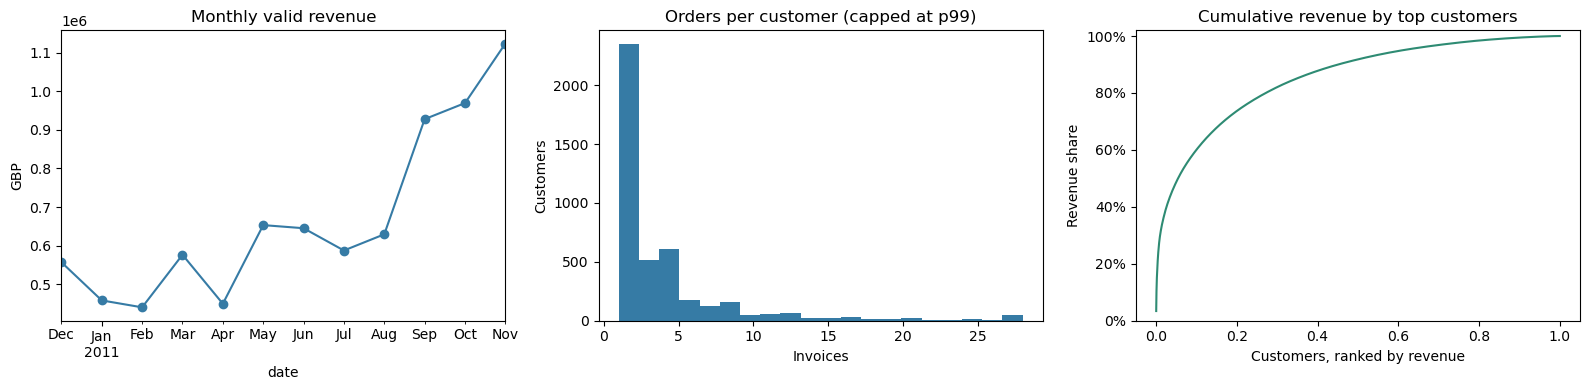

Top 10% of customers account for 60% of revenue


In [23]:
invoice_level = (clean.groupby(["CustomerID", "InvoiceNo"], as_index=False)
                 .agg(date=("InvoiceDate", "min"), revenue=("TotalPrice", "sum")))
monthly_revenue = invoice_level.set_index("date")["revenue"].resample("MS").sum()

orders_per_customer = invoice_level.groupby("CustomerID").size()
customer_revenue = invoice_level.groupby("CustomerID")["revenue"].sum().sort_values(ascending=False)
revenue_share = customer_revenue.cumsum() / customer_revenue.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
monthly_revenue.plot(ax=axes[0], marker="o", title="Monthly valid revenue", color="#367ba5")
axes[0].set_ylabel("GBP")

axes[1].hist(orders_per_customer.clip(upper=orders_per_customer.quantile(0.99)),
             bins=20, color="#367ba5")
axes[1].set(title="Orders per customer (capped at p99)", xlabel="Invoices", ylabel="Customers")

axes[2].plot(np.arange(1, len(revenue_share) + 1) / len(revenue_share), revenue_share.values,
             color="#2e8b73")
axes[2].set(title="Cumulative revenue by top customers",
            xlabel="Customers, ranked by revenue", ylabel="Revenue share", ylim=(0, 1.02))
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1))

fig.tight_layout(); plt.show(); plt.close(fig)

top_10pct_share = customer_revenue.head(max(1, int(len(customer_revenue) * 0.10))).sum() / customer_revenue.sum()
print(f"Top 10% of customers account for {top_10pct_share*100:.0f}% of revenue")

##### Revenue concentration shows that customers should not all be treated the same
The top 10% of customers account for 60% of observed revenue, and the order-count
histogram has a long right tail even after capping the plot at its 99th percentile --
most customers buy once or twice, a minority buy repeatedly and often. Monthly revenue
rises sharply into September-November, but those are holdout-window months by this
project's own decision clock, so that rise is a descriptive pattern here, not a feature
or evidence of seasonality that any model gets to see. Revenue concentration is the
direct motivation for segmentation-based CLV work (notebook 2) rather than a single
average-customer number.

In [24]:
country_revenue = (clean.groupby("Country")["TotalPrice"].sum()
                    .sort_values(ascending=False))
(country_revenue / country_revenue.sum() * 100).round(1).head(10)

Country
United Kingdom    82.1
Netherlands        3.4
EIRE               3.0
Germany            2.5
France             2.2
Australia          1.7
Switzerland        0.6
Spain              0.6
Japan              0.5
Sweden             0.5
Name: TotalPrice, dtype: float64

**Note:** the dataset is overwhelmingly UK-based by revenue too. This project doesn't
restrict to UK-only customers -- international customers are a small share and there's
no clear reason to throw away their history -- but it's worth knowing this analysis is
implicitly UK-dominated.

### Invariant checks

A handful of assertions that should hold no matter what, plus a look at the largest
reversed transactions -- exactly the kind of extreme case that hid the original
phantom-revenue bug.

In [25]:
assert clean["CustomerID"].notna().all()
assert clean["InvoiceDate"].lt(OBSERVATION_END).all()
assert clean["InvoiceDate"].ge(DATA_START).all()
assert clean["TotalPrice"].gt(0).all()
assert clean.duplicated().sum() == 0
assert (clean["InvoiceNo"].str.upper().str.startswith("C")).sum() == 0
assert matched["cancelled_at"].ge(matched["purchase_at"]).all(), "a cancellation before its own purchase would be a bug"
print("All invariants hold.")

All invariants hold.


In [26]:
matched_with_value = matched.assign(
    unit_revenue=(raw.loc[matched["purchase_row"], "Quantity"].to_numpy()
                  * raw.loc[matched["purchase_row"], "UnitPrice"].to_numpy()))
matched_with_value.nlargest(5, "unit_revenue")[["purchase_at", "cancelled_at", "unit_revenue"]]

,purchase_at,cancelled_at,unit_revenue
0,2011-01-18 10:01:00,2011-01-18 10:17:00,77183.60
1792,2011-01-11 12:55:00,2011-04-18 13:08:00,6539.40
1795,2011-01-11 12:55:00,2011-04-18 13:08:00,4921.50
1794,2011-01-11 12:57:00,2011-04-18 13:08:00,4522.50
2289,2011-09-20 11:05:00,2011-09-21 09:16:00,3825.36


The largest matched reversal is the same £77,183.60 order flagged in the first
iteration -- placed and cancelled 16 minutes apart. It's correctly excluded here, same
as before. A surviving transaction of similar size, if one existed, would be worth a
separate influence check in the notebooks that use revenue as a model input.

### Save data for next steps

Persisting the cleaned transaction table plus the split-off cancellations and matched-pairs
tables -- the latter two aren't used directly downstream but are worth keeping in case a
future notebook needs to audit a specific customer's history.

In [27]:
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

clean.to_parquet(PROCESSED_DATA / "online_retail_clean.parquet", index=False)
cancellations.to_parquet(PROCESSED_DATA / "retail_cancellations.parquet", index=False)
matched.to_parquet(PROCESSED_DATA / "retail_matched_reversals.parquet", index=False)
audit_df.to_csv(PROCESSED_DATA / "retail_etl_audit.csv", index=False)

print("Saved clean transaction table and ETL audits")

Saved clean transaction table and ETL audits


### Summary

- Fixed a single decision clock (`CALIBRATION_END` = 2011-09-01, `OBSERVATION_END` =
  2011-12-01) that every later notebook in this project inherits unchanged -- the
  structural fix motivated by the first iteration's post-mortem.
- Started from the raw transaction table (see `audit_df` above for exact row counts) and
  retained a clean, analysis-ready set after removing missing-customer rows, exact
  duplicates, the partial December 2011 month, cancelled orders, non-product line items,
  and non-positive quantities/prices.
- The cancellation fix is now **decision-clock-aware**: a reversal only removes its
  matching purchase if that reversal was knowable at the relevant cutoff. This kept 196
  calibration purchases that the first iteration's simpler fix would have removed.
- Revenue is highly concentrated across customers, setting up segmentation-based (not
  average-based) CLV work in the next notebook.

**Next:** `02_Population_Historic_Value_RFM_and_Cohorts.ipynb` -- define the one
eligible customer population every later notebook shares, compute historic CLV,
decision-time RFM segments, and cohort retention.